In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path

import sys

NOTEBOOK_DIR = Path.cwd()
API_SRC = (NOTEBOOK_DIR.parent / "api" / "src").resolve()

sys.path.insert(0, str(API_SRC))

from gena_expression.conditions import DescriptionLookup
from gena_expression.contexts import Genome
from gena_expression.inference import SequenceModel
from gena_expression.tracks import Track

In [ ]:
# Paths and constants used by later cells
GENA_LM_ROOT = Path("/home/jovyan/dpanc/GENA_LM") / "GENA_LM_expression_branch" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/home/jovyan/dpanc/benchmarking/GENA_LM/models/full_model/pytorch_model.bin") # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "atac_seq_predictions/inference_portable.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DESCRIPTION_DIR = Path("/home/jovyan/dpanc/GENA_LM/GENA_LM_expression_branch/downstream_tasks/expression_prediction/api/data/atacseq_generated_descriptions")

GENOME_FASTA = Path("/home/jovyan/dpanc/komarek/data/T2Thuman_AsteI2_plm_merged_ref.fa") # CHANGE THIS LINE

DEVICE = "cuda:0"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

We will use ATAC-seq experiment from ENCODE as an example: https://www.encodeproject.org/files/ENCFF770EAV/@@download/ENCFF770EAV.bigWig

In [8]:
genome = Genome(
    fasta_path=GENOME_FASTA
)

In [5]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=15,
    device=DEVICE,
)

/home/jovyan/dpanc/GENA_LM/GENA_LM_expression_branch/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:162: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

In [11]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=['HEK293'],
)

In [35]:
sequence = genome.sequence_around(center=120524275, chrom='chr1', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['HEK293'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr1',
              center=120524275,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

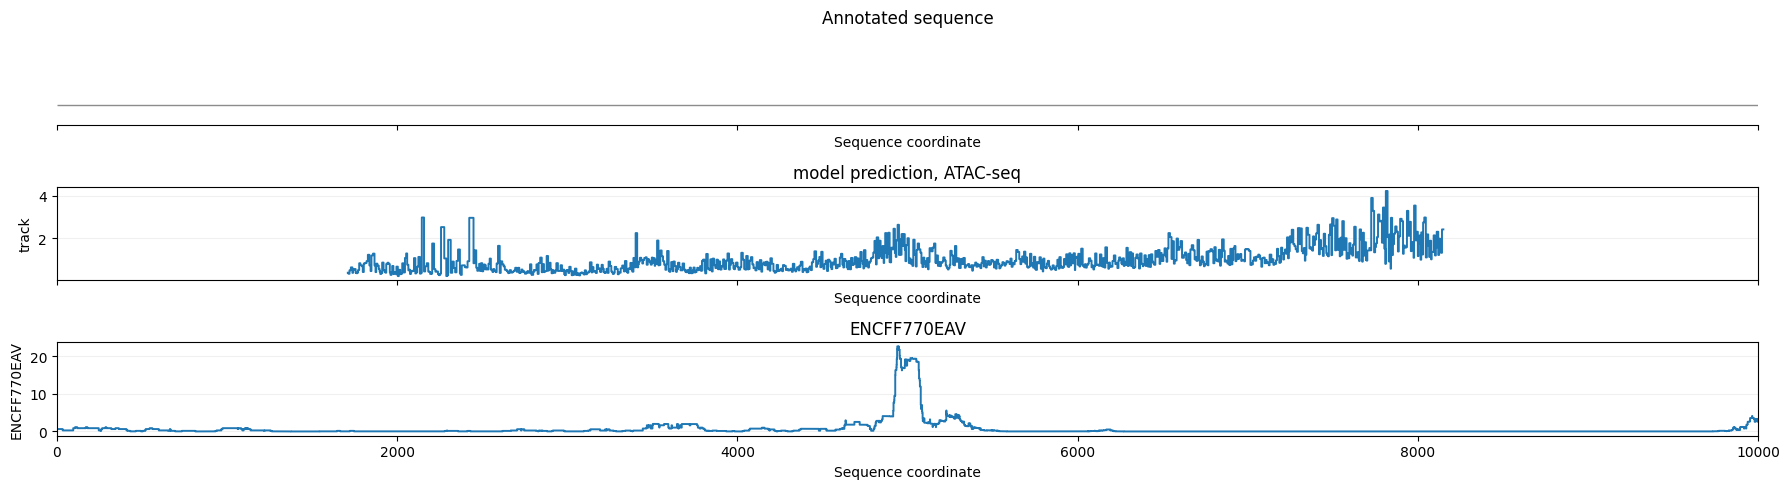

In [36]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

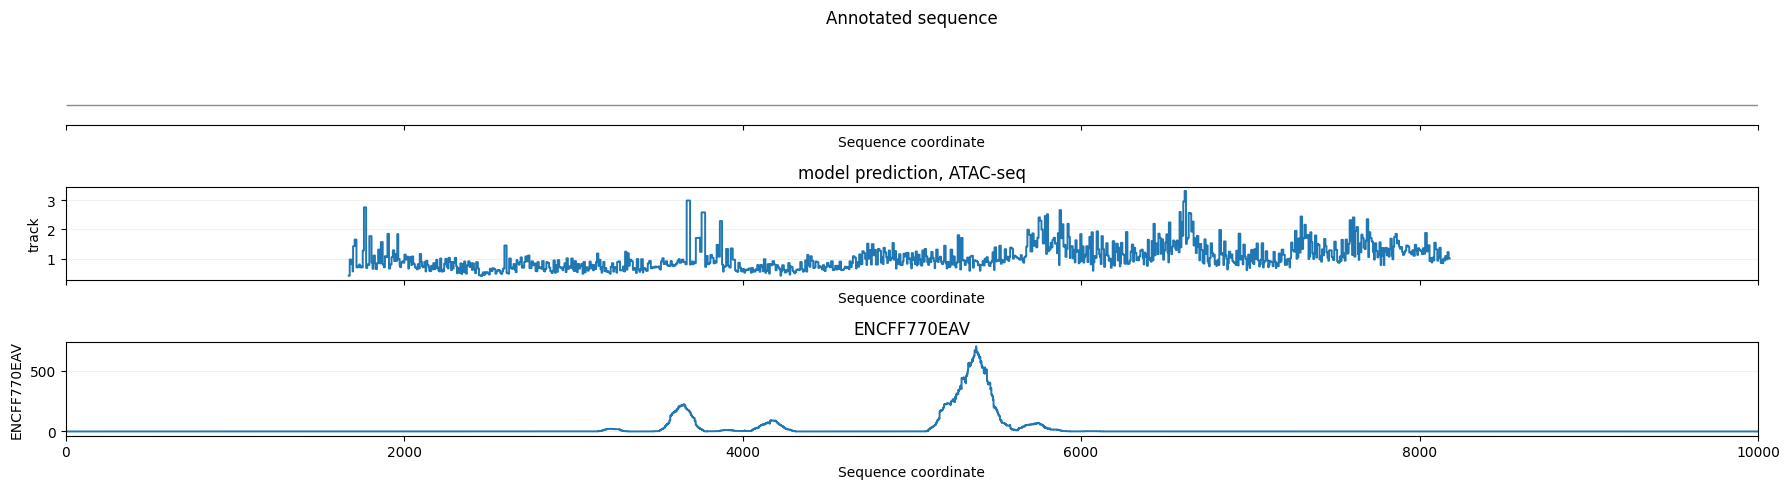

In [38]:
sequence = genome.sequence_around(center=178_480_000, chrom='chr2', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['HEK293'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr2',
              center=178_480_000,
              size=10_000)
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [20]:
# Mean prediction across tokens overlapping the central 50 bp
track_df = prediction.track().to_frame()
window_start, window_end = 5000 - 25, 5000 + 25

center_tokens = track_df[
    (track_df["end"] > window_start)
    & (track_df["start"] < window_end)
].copy()

center_50bp_mean = center_tokens["track"].mean()
print("Number of overlapping tokens:", len(center_tokens))
print("Central 50-bp token mean:", center_50bp_mean)
center_tokens[["token", "start", "end", "track"]]


Number of overlapping tokens: 9
Central 50-bp token mean: 0.5069444444444444


,token,start,end,track
506,ATGTGC,4971,4977,0.341797
507,ATGTGTC,4977,4984,0.359375
508,TTTAT,4984,4989,0.373047
509,AGTAGAATG,4989,4998,0.574219
510,AC,4998,5000,0.519531
511,TTATAA,5000,5006,0.347656
512,TCC,5006,5009,0.445312
513,TTTGGGTATATACCC,5009,5024,0.949219
514,AGTAATGGG,5024,5033,0.652344
